# JOB MARKET DATA ANALYSIS
## Prediction and Exploratory Data Analysis Report



## Introduction
This project analyzes AI job market data to understand salary trends, experience levels, skills demand, and job distribution across industries.

## Dataset Description
The dataset contains information such as:
- job title
- company size
- experience level
- salary
- skills (Python, SQL, ML, etc.)

In [1]:
# import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("AI_jobs.csv")

# Show first rows
df.head()

,job_id,job_title,company_size,company_industry,country,remote_type,experience_level,years_experience,education_level,skills_python,skills_sql,skills_ml,skills_deep_learning,skills_cloud,salary,job_posting_month,job_posting_year,hiring_urgency,job_openings
0,1,AI Engineer,Startup,Retail,Canada,Remote,Senior,2,Master,0,0,0,1,0,158322,6,2024,Low,4
1,2,Machine Learning Engineer,MNC,Technology,Australia,Hybrid,Mid,0,Bachelor,1,1,1,0,1,163666,11,2026,High,9
2,3,Machine Learning Engineer,MNC,Technology,Germany,Onsite,Mid,14,Master,1,0,1,0,1,158556,3,2026,High,9
3,4,Business Analyst,Startup,Healthcare,Germany,Remote,Mid,9,Master,0,1,0,1,1,95775,3,2025,High,7
4,5,Data Scientist,MNC,Healthcare,Germany,Hybrid,Mid,5,Master,1,1,1,0,0,111873,12,2021,Low,2


## data information

In [2]:
df.info()
df.describe()
df.columns

<class 'pandas.DataFrame'>
RangeIndex: 10345 entries, 0 to 10344
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   job_id                10345 non-null  int64
 1   job_title             10345 non-null  str  
 2   company_size          10345 non-null  str  
 3   company_industry      10345 non-null  str  
 4   country               10345 non-null  str  
 5   remote_type           10345 non-null  str  
 6   experience_level      10345 non-null  str  
 7   years_experience      10345 non-null  int64
 8   education_level       10345 non-null  str  
 9   skills_python         10345 non-null  int64
 10  skills_sql            10345 non-null  int64
 11  skills_ml             10345 non-null  int64
 12  skills_deep_learning  10345 non-null  int64
 13  skills_cloud          10345 non-null  int64
 14  salary                10345 non-null  int64
 15  job_posting_month     10345 non-null  int64
 16  job_posting_yea

Index(['job_id', 'job_title', 'company_size', 'company_industry', 'country',
       'remote_type', 'experience_level', 'years_experience',
       'education_level', 'skills_python', 'skills_sql', 'skills_ml',
       'skills_deep_learning', 'skills_cloud', 'salary', 'job_posting_month',
       'job_posting_year', 'hiring_urgency', 'job_openings'],
      dtype='str')

## data cleaning

In [3]:
# Check missing values
df.isnull().sum()

# Remove duplicates
df = df.drop_duplicates()

# Convert salary to numeric 
df['salary'] = pd.to_numeric(df['salary'], errors='coerce')

# save the cleaned data for analysis

In [4]:
df.to_csv("clean_jobs_data.csv", index=False)

In [5]:
# load the cleaned data
df = pd.read_csv("clean_jobs_data.csv")

## Salary Analysis by Job Title

In [6]:
salary_by_job = df.groupby('job_title')['salary'].mean().sort_values(ascending=False)
salary_by_job

job_title
AI Engineer                  139945.210677
Machine Learning Engineer    139705.422989
Business Analyst             101642.028765
Data Engineer                 99711.085322
Data Scientist                99645.837933
Data Analyst                  99136.475745
Name: salary, dtype: float64

## Salary vs Experience Level
- how salary grows with experience

In [7]:
df.groupby('experience_level')['salary'].mean()

experience_level
Entry      89095.872758
Mid       113592.018464
Senior    138289.091520
Name: salary, dtype: float64

## Remote Work Analysis
- Do remote jobs pay more?

In [8]:
df.groupby('remote_type')['salary'].mean()

remote_type
Hybrid    113363.757018
Onsite    113649.938453
Remote    113305.101623
Name: salary, dtype: float64

## Skills Demand Analysis
- Most demanded skills

In [9]:
skills = ['skills_python', 'skills_sql', 'skills_ml', 'skills_deep_learning', 'skills_cloud']
df[skills].sum().sort_values(ascending=False)

skills_cloud            5291
skills_ml               5254
skills_sql              5204
skills_deep_learning    5152
skills_python           5101
dtype: int64

## Job Openings Analysis
- the roles which are in the highest demand

In [10]:
df.groupby('job_title')['job_openings'].sum().sort_values(ascending=False)

job_title
Business Analyst             8940
Machine Learning Engineer    8767
Data Scientist               8659
Data Analyst                 8632
AI Engineer                  8483
Data Engineer                8286
Name: job_openings, dtype: int64

## Monthly Hiring Trends

In [11]:
df.groupby('job_posting_month')['job_openings'].sum()

job_posting_month
1     4569
2     4197
3     4256
4     4303
5     4244
6     4394
7     3944
8     4197
9     4271
10    4351
11    4469
12    4572
Name: job_openings, dtype: int64

## salary increases as experience increases

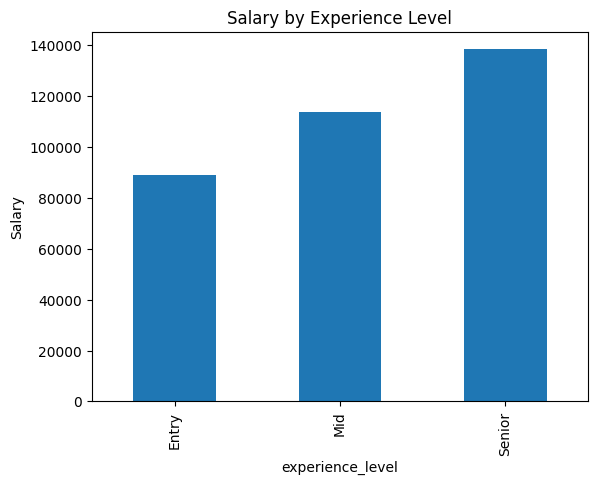

In [12]:
df.groupby('experience_level')['salary'].mean().plot(kind='bar')
plt.title("Salary by Experience Level")
plt.ylabel("Salary")
plt.show()

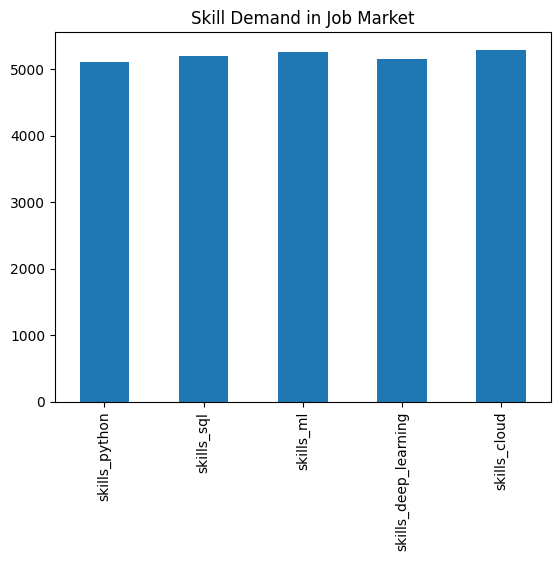

In [13]:
skills = ['skills_python','skills_sql','skills_ml','skills_deep_learning','skills_cloud']

df[skills].sum().plot(kind='bar')
plt.title("Skill Demand in Job Market")
plt.show()

## work flexibility trends

## market demands

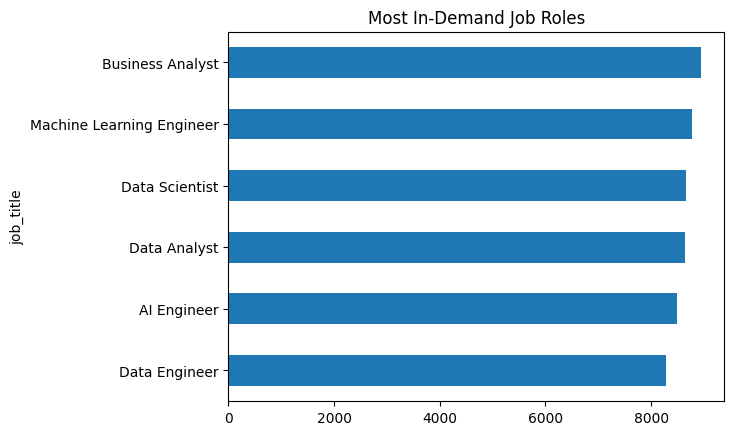

In [14]:
df.groupby('job_title')['job_openings'].sum().sort_values().tail(10).plot(kind='barh')
plt.title("Most In-Demand Job Roles")
plt.show()


## Key Findings/insights
- Higher experience leads to higher salary
- cloud and machine learning are the most demanded skills
- Most jobs are full-time positions


## Conclusion
The analysis shows that experience and technical skills strongly influence salary in AI-related jobs.